# Descriptive Behavior Analysis

In [ ]:
import pandas as pd
df = pd.read_csv('CleanedData.csv')
df.head()

,Unnamed: 0,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction
0,0,2023/06/07 11:06:40 PM GMT+5:30,59,Others,Once a week,Beauty and Personal Care,Few times a month,others,Multiple pages,4,...,Yes,Rarely,No,1,Yes,3,3,Customer service,User interface of app,433348
1,1,2023/06/06 7:08:47 PM GMT+5:30,48,Female,Once a month,Beauty and Personal Care;Clothing and Fashion;...,Rarely,categories,Multiple pages,1,...,No,Never,Sometimes,1,No,5,2,.,.,735054
2,2,2023/06/08 9:39:30 PM GMT+5:30,57,Prefer not to say,Multiple times a week,Groceries and Gourmet Food,Rarely,Keyword,First page,2,...,Yes,Rarely,No,5,Sometimes,3,3,Customer service,Product quality and accuracy,119350
3,3,2023/06/07 9:22:24 PM GMT+5:30,30,Others,Few times a month,Groceries and Gourmet Food;Beauty and Personal...,Few times a month,others,Multiple pages,2,...,Yes,Rarely,Sometimes,4,Sometimes,4,5,Customer service,.,180686
4,4,2023/06/06 7:21:26 PM GMT+5:30,51,Female,Once a month,Groceries and Gourmet Food;Beauty and Personal...,Few times a month,Filter,First page,5,...,Yes,Moderately,Sometimes,1,Yes,3,1,.,I don't have any problem with Amazon,538184


In [ ]:
df.drop(columns=['Unnamed: 0'],inplace=True)
df.columns

Index(['Timestamp', 'age', 'Gender', 'Purchase_Frequency',
       'Purchase_Categories', 'Browsing_Frequency', 'Product_Search_Method',
       'Search_Result_Exploration', 'Customer_Reviews_Importance',
       'Add_to_Cart_Browsing', 'Cart_Completion_Frequency',
       'Cart_Abandonment_Factors', 'Saveforlater_Frequency', 'Review_Left',
       'Review_Reliability', 'Review_Helpfulness',
       'Personalized_Recommendation_Frequency', 'Recommendation_Helpfulness',
       'Rating_Accuracy', 'Shopping_Satisfaction', 'Service_Appreciation',
       'Improvement_Areas', 'transaction'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   Timestamp                              800 non-null    object
 1   age                                    800 non-null    int64 
 2   Gender                                 800 non-null    object
 3   Purchase_Frequency                     800 non-null    object
 4   Purchase_Categories                    800 non-null    object
 5   Browsing_Frequency                     800 non-null    object
 6   Product_Search_Method                  800 non-null    object
 7   Search_Result_Exploration              800 non-null    object
 8   Customer_Reviews_Importance            800 non-null    int64 
 9   Add_to_Cart_Browsing                   800 non-null    object
 10  Cart_Completion_Frequency              800 non-null    object
 11  Cart_Abandonment_Fa

## Summarizing Customer Demographics

In [ ]:
#Gender Distribution - Almost same with slight male dominance
df['Gender'].value_counts(normalize=True).round(3)*100

,proportion
Gender,
Male,26.6
Female,25.1
Prefer not to say,24.2
Others,24.0


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

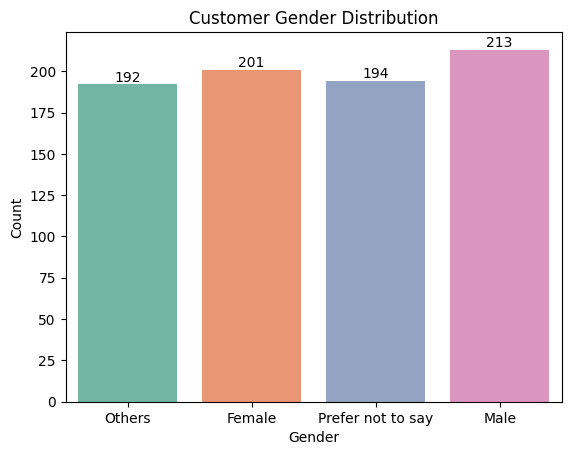

In [ ]:
ax = sns.countplot(data=df,x='Gender', hue='Gender', palette='Set2')
for p in ax.containers:
  ax.bar_label(p)
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Customer Gender Distribution')
plt.show()

In [ ]:
df['age'].agg(['min','max','mean','median','std'])

,age
min,3.000000
max,67.000000
mean,36.053750
median,37.000000
std,19.310087


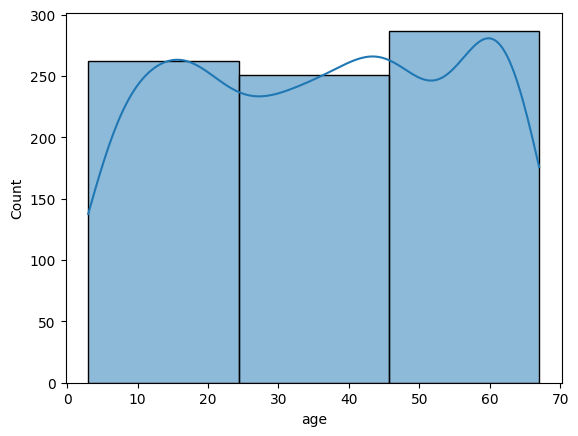

In [ ]:
# Age Distribution (< 25, 25 to 45, 45 to 65)
sns.histplot(data=df,x='age',kde=True, bins=3);

##  Purchase Frequency Analysis


In [ ]:
# Almost 21% of customers are frequent shoppers
df['Purchase_Frequency'].value_counts(normalize=True).round(4)*100

,proportion
Purchase_Frequency,
Multiple times a week,20.75
Once a month,20.50
Once a week,20.13
Few times a month,19.62
Less than once a month,19.00


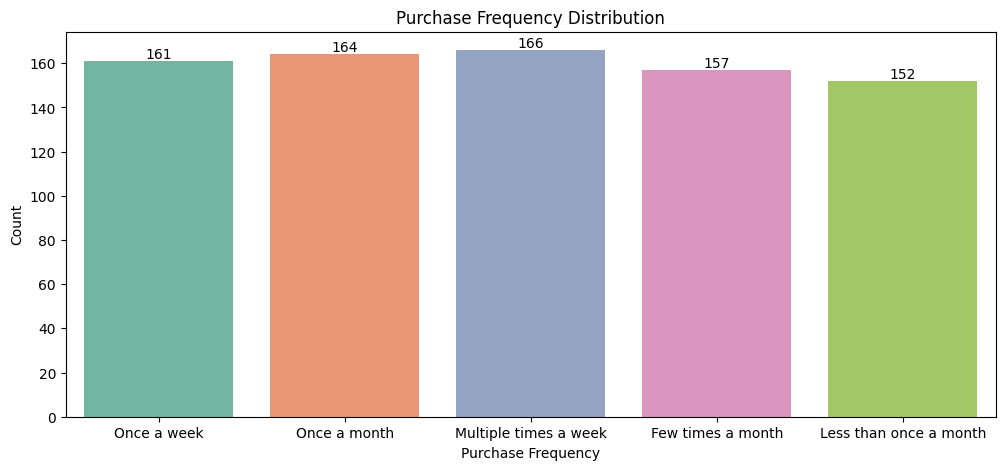

In [ ]:
fig = plt.figure(figsize=(12,5))
ax = sns.countplot(data=df,x='Purchase_Frequency', hue='Purchase_Frequency', palette='Set2')
for p in ax.containers:
  ax.bar_label(p)
plt.xlabel('Purchase Frequency')
plt.ylabel('Count')
plt.title('Purchase Frequency Distribution')
plt.show()

In [ ]:
# Product Categories are mixed here - We have to split
df['Purchase_Categories'].unique()

array(['Beauty and Personal Care',
       'Beauty and Personal Care;Clothing and Fashion;Home and Kitchen',
       'Groceries and Gourmet Food',
       'Groceries and Gourmet Food;Beauty and Personal Care;Clothing and Fashion',
       'Groceries and Gourmet Food;Beauty and Personal Care;Clothing and Fashion;Home and Kitchen',
       'Groceries and Gourmet Food;Beauty and Personal Care;Clothing and Fashion;Home and Kitchen;others',
       'Groceries and Gourmet Food;Clothing and Fashion;Home and Kitchen',
       'Groceries and Gourmet Food;Beauty and Personal Care;others',
       'Clothing and Fashion',
       'Beauty and Personal Care;Clothing and Fashion;Home and Kitchen;others',
       'Clothing and Fashion;Home and Kitchen', 'others',
       'Beauty and Personal Care;Clothing and Fashion',
       'Groceries and Gourmet Food;Clothing and Fashion;others',
       'Clothing and Fashion;Home and Kitchen;others',
       'Home and Kitchen;others',
       'Groceries and Gourmet Food;Beauty 

In [ ]:
df_categories = df.copy()

In [ ]:
# Splitting delimeter is ;
df_categories['Purchase_Categories'] = df_categories['Purchase_Categories'].str.split(';')

In [ ]:
# Splitting gave us a list of separated categories
df_categories['Purchase_Categories'].head()

,Purchase_Categories
0,[Beauty and Personal Care]
1,"[Beauty and Personal Care, Clothing and Fashio..."
2,[Groceries and Gourmet Food]
3,"[Groceries and Gourmet Food, Beauty and Person..."
4,"[Groceries and Gourmet Food, Beauty and Person..."


In [ ]:
# Splitting row wise for each category in the list
df_categories = df_categories.explode('Purchase_Categories')

In [ ]:
# Now we are getting proper 5 unique Product Categories
df_categories['Purchase_Categories'].unique()

array(['Beauty and Personal Care', 'Clothing and Fashion',
       'Home and Kitchen', 'Groceries and Gourmet Food', 'others'],
      dtype=object)

In [ ]:
# Clothing and Fashion is the Most Popular Product Category
df_categories['Purchase_Categories'].value_counts(normalize=True).round(4)*100

,proportion
Purchase_Categories,
Clothing and Fashion,22.97
Beauty and Personal Care,19.98
Home and Kitchen,19.55
others,19.11
Groceries and Gourmet Food,18.39


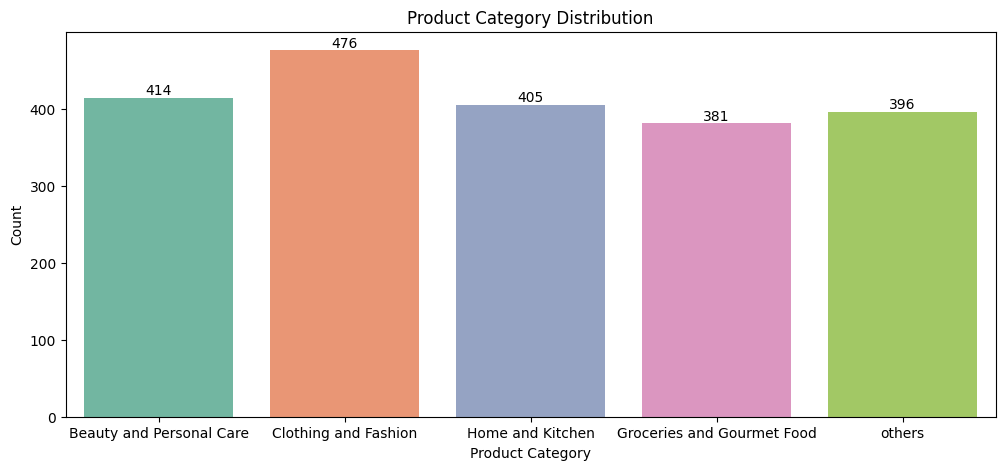

In [ ]:
fig = plt.figure(figsize=(12,5))
ax = sns.countplot(data=df_categories,x='Purchase_Categories', hue='Purchase_Categories', palette='Set2')
for p in ax.containers:
  ax.bar_label(p)
plt.xlabel('Product Category')
plt.ylabel('Count')
plt.title('Product Category Distribution')
plt.show()

In [ ]:
# Clothing and Fashion Category drives the most demand
# SnapDeal can do inventory planning prioritizing this category
# then Beauty and Personal Care products

## Top Browsing Methods

In [ ]:
# Apart from others, Keyword Search Method is top most Browsing Method by customers
# They are intentional shoppers. They want specific products
# We can implement autocomplete feature and search model should recognise synonyms
df['Product_Search_Method'].value_counts(normalize=True).round(4)*100

,proportion
Product_Search_Method,
others,22.75
Keyword,20.37
categories,19.50
Filter,18.75
Unknown,18.62


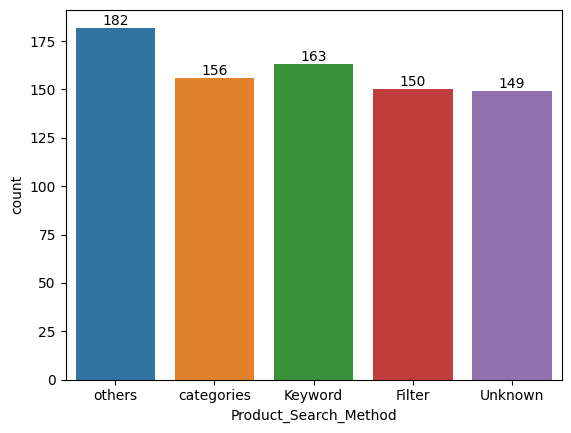

In [ ]:
ax = sns.countplot(data=df,x='Product_Search_Method', hue='Product_Search_Method', palette='tab10');
for p in ax.containers:
  ax.bar_label(p)

## Top Cart Abandonment Reasons

In [ ]:
# Main cart abandonment reason was they found better price elsewhere
df['Cart_Abandonment_Factors'].value_counts(normalize=True).round(4)*100

,proportion
Cart_Abandonment_Factors,
Found a better price elsewhere,27.38
others,24.50
High shipping costs,24.25
Changed my mind or no longer need the item,23.88


In [ ]:
# It tells that users are highly sensitive for the product pricing.
# They prioritize budget over brand loyalty
# We can implement Price Matching Offers and Time Limited Discount to build
# Customer loyalty and minimise cart abandonment

## Satisfaction, Recommendation Helpfulness, and Rating Accuracy

In [ ]:
df.columns

Index(['Timestamp', 'age', 'Gender', 'Purchase_Frequency',
       'Purchase_Categories', 'Browsing_Frequency', 'Product_Search_Method',
       'Search_Result_Exploration', 'Customer_Reviews_Importance',
       'Add_to_Cart_Browsing', 'Cart_Completion_Frequency',
       'Cart_Abandonment_Factors', 'Saveforlater_Frequency', 'Review_Left',
       'Review_Reliability', 'Review_Helpfulness',
       'Personalized_Recommendation_Frequency', 'Recommendation_Helpfulness',
       'Rating_Accuracy', 'Shopping_Satisfaction', 'Service_Appreciation',
       'Improvement_Areas', 'transaction'],
      dtype='object')

In [ ]:
score_mapping = {
    'Yes': 3,
    'Sometimes': 2,
    'No': 1
}
df['Recommendation_Helpfulness'] = df['Recommendation_Helpfulness'].map(score_mapping)


In [ ]:
df[['Shopping_Satisfaction','Recommendation_Helpfulness','Rating_Accuracy']].agg(
    ['min','max','mean','median','std']
)

,Shopping_Satisfaction,Recommendation_Helpfulness,Rating_Accuracy
min,1.000000,1.000000,1.00000
max,5.000000,3.000000,5.00000
mean,2.988750,1.957500,2.96375
median,3.000000,2.000000,3.00000
std,1.407515,0.833103,1.42565


In [ ]:
# Satisfaction and Rating Accuracy have mean approx. 3 out of 5 (Average)
# Recommendation Helpfulness have mean approx. 2 out of 3 (Average)
# Mean almost equal to Median shows approx Normal distribution

## Summary Statistics

In [ ]:
df.describe()

,age,Customer_Reviews_Importance,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,transaction
count,800.000000,800.000000,800.000000,800.000000,800.00000,800.000000,800.00000
mean,36.053750,2.988750,2.911250,1.957500,2.96375,2.988750,547442.01375
std,19.310087,1.400384,1.405647,0.833103,1.42565,1.407515,255993.34801
min,3.000000,1.000000,1.000000,1.000000,1.00000,1.000000,101141.00000
25%,18.000000,2.000000,2.000000,1.000000,2.00000,2.000000,322742.75000
50%,37.000000,3.000000,3.000000,2.000000,3.00000,3.000000,541612.50000
75%,53.000000,4.000000,4.000000,3.000000,4.00000,4.000000,765374.75000
max,67.000000,5.000000,5.000000,3.000000,5.00000,5.000000,998820.00000


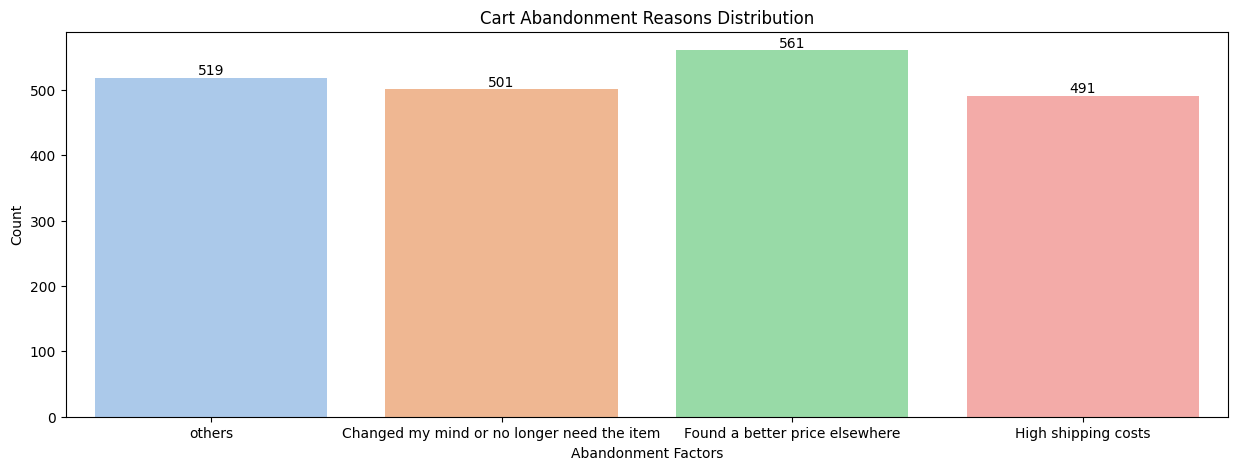

In [ ]:
fig = plt.figure(figsize=(15,5))
ax = sns.countplot(data=df_categories,x='Cart_Abandonment_Factors', hue='Cart_Abandonment_Factors', palette='pastel')
for p in ax.containers:
  ax.bar_label(p)
plt.xlabel('Abandonment Factors')
plt.ylabel('Count')
plt.title('Cart Abandonment Reasons Distribution')
plt.show()

In [ ]:
df['Cart_Completion_Frequency'].unique()

array(['Rarely', 'Often', 'Never', 'Sometimes', 'Always'], dtype=object)

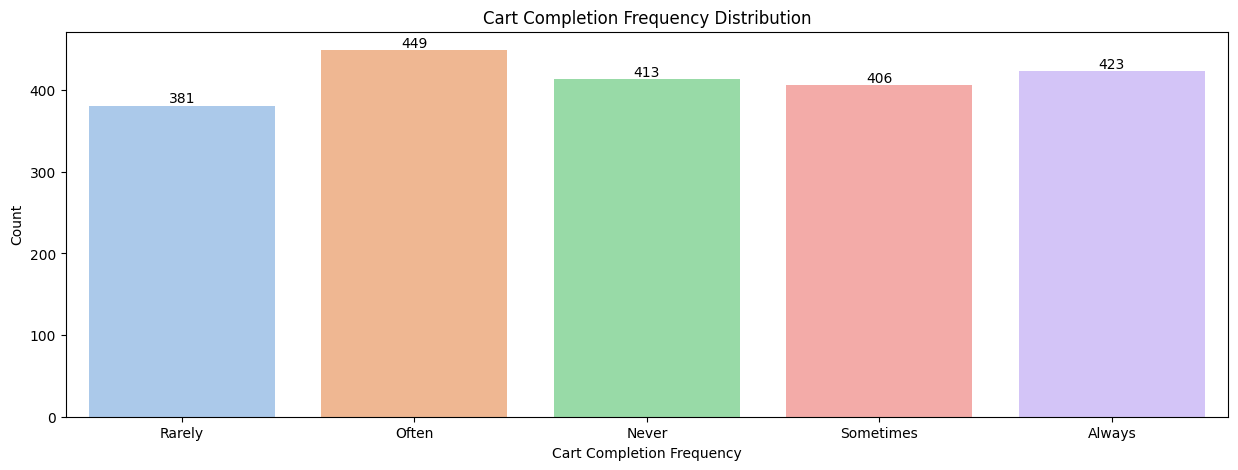

In [ ]:
fig = plt.figure(figsize=(15,5))
ax = sns.countplot(data=df_categories,x='Cart_Completion_Frequency', hue='Cart_Completion_Frequency', palette='pastel')
for p in ax.containers:
  ax.bar_label(p)
plt.xlabel('Cart Completion Frequency')
plt.ylabel('Count')
plt.title('Cart Completion Frequency Distribution')
plt.show()

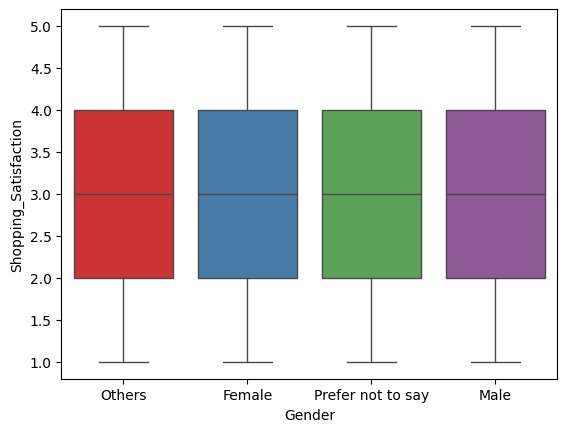

In [ ]:
sns.boxplot(data=df, x='Gender', y='Shopping_Satisfaction', hue='Gender', palette='Set1');